# Pandas Chart Types

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
df1 = pd.DataFrame({
    'A': np.arange(100),
    'B': np.random.randn(100).cumsum(),
    'C': np.random.randn(100).cumsum(),
})
df2 = pd.DataFrame({
    'a': np.random.rand(50),
    'b': np.random.rand(50),
    'c': np.random.rand(50),
})
df = pd.DataFrame(np.random.randn(1000, 2), columns=['a', 'b'])
tips = sns.load_dataset('tips')

```{contents}
:local:
:depth: 2
```


## Common Chart Types

In [10]:
if "np" not in globals():
    import numpy as np
if "pd" not in globals():
    import pandas as pd
if "plt" not in globals():
    import matplotlib.pyplot as plt
if "sns" not in globals():
    import seaborn as sns

### Line Plots

In [11]:
flights = sns.load_dataset("flights")

flights.groupby("year")["passengers"].sum().plot(
    kind="line",
    figsize=(5, 3),
    fontsize=8,
    title="Total Passengers per Year",
    marker="o"      # show data points
)
plt.tight_layout()

NameError: name 'flights' is not defined

### Histograms

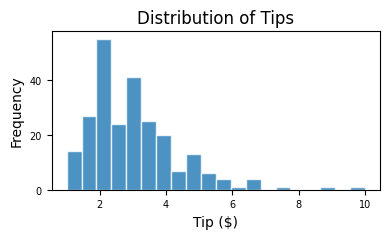

In [ ]:
tips = sns.load_dataset("tips")

# ax = tips["tip"].plot(        ### plot() returns the Axes object, 
                                ### so we can capture it in a variable
tips["tip"].plot(
    kind="hist",
    figsize=(4, 2.5),
    bins=20,
    edgecolor="white",
    alpha=0.8,
    fontsize=7,
    title="Distribution of Tips"
)

plt.xlabel("Tip ($)")
plt.ylabel("Frequency")
plt.tight_layout()

### Scatter Plot

<Axes: title={'center': 'Basic'}, xlabel='total_bill', ylabel='tip'>

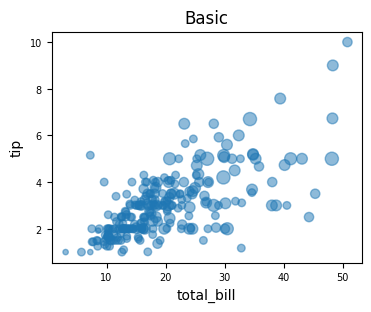

In [ ]:
tips = sns.load_dataset("tips")

tips.plot(
    kind="scatter",
    x="total_bill", y="tip",
    alpha=0.5, fontsize=7,
    title="Basic",
    figsize=(4, 3),
    s=tips["size"] * 15     ### scale size by 'size' column
)

### Bar Plots

Bar plots are one of the most common ways to compare categorical data visually. They represent quantities as rectangular bars whose length (or height) corresponds to the value being measured.

Both bar() and barh() create bar charts — the difference is simply orientation. Stacked bar charts, on the other hand, how multiple subcategories contribute to a total within each main category.  

| Plot Type       | Orientation | Purpose                                  | Best For                                |
| --------------- | ----------- | ---------------------------------------- | --------------------------------------- |
| **Bar Plot**    | Vertical    | Compare category values                  | Simple category comparisons             |
| **Barh Plot**   | Horizontal  | Compare category values with long labels | Readability and ranking-type data       |
| **Stacked Bar** | Either      | Show part-to-whole relationships         | Composition of totals across categories |



#### Vertical Bar Plot

In [ ]:
tips = sns.load_dataset("tips")
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


<Axes: xlabel='day'>

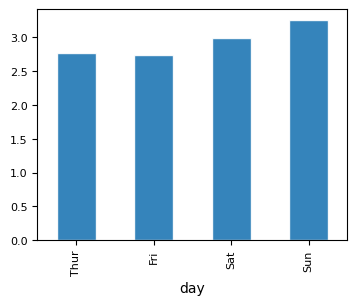

In [ ]:
### bar plot
tips.groupby("day", observed=True)["tip"].mean().plot(kind="bar", 
        figsize=(4, 3), edgecolor="white", alpha=0.9, fontsize=8)

#### Horizontal Bar Plot 

<Axes: ylabel='day'>

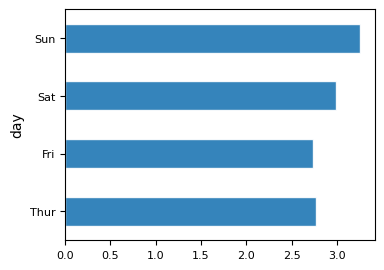

In [ ]:
### bar plot horizontal

tips.groupby("day", observed=True)["tip"].mean().plot(kind="barh", 
        figsize=(4, 3), edgecolor="white", alpha=0.9, fontsize=8)

#### Stacked Bar Plot

<Axes: xlabel='class'>

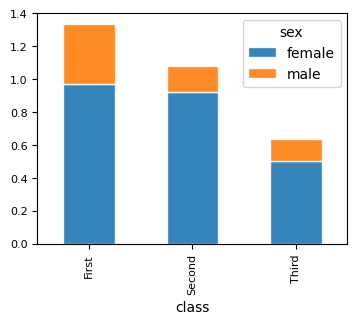

In [ ]:
### titanic — survival count by gender and class
titanic = sns.load_dataset("titanic")

titanic.groupby(["class", "sex"], observed=True)["survived"].mean()\
    .unstack().plot(kind="bar", 
    stacked=True,
    figsize=(4, 3), edgecolor="white", alpha=0.9, fontsize=8)

### BoxPlots

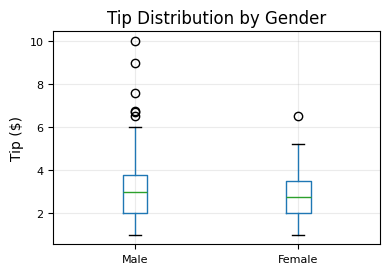

In [ ]:
tips.boxplot(
    column="tip",
    by="sex",
    figsize=(4, 3),
    fontsize=8
)
plt.suptitle("")        # removes default "Boxplot grouped by sex" title
plt.title("Tip Distribution by Gender")
plt.xlabel("")
plt.ylabel("Tip ($)")
plt.grid(alpha=0.25)
plt.tight_layout()

### Area Plot

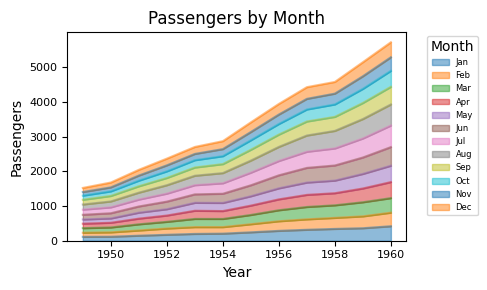

In [ ]:
flights = sns.load_dataset("flights")

df = flights.pivot(index="year", columns="month", values="passengers")

df.plot(
    kind="area",
    figsize=(5, 3),
    alpha=0.5,
    fontsize=8,
    title="Passengers by Month"
)

plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend(title="Month", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=6)
plt.tight_layout()

### KDE Plot

- A Kernel Density Estimate (KDE) plot is smooth version of histogram. 
- Density tells you where values are concentrated. A higher curve means more values are packed in that region. The exact y-value doesn't matter — the shape and peaks are what you read.
  - The peak shows where most values are concentrated
  - A wider curve means more spread in the data
  - The area under the curve always equals 1.0
  - The y-axis shows density — not count or percentage

  species     island  body_mass_g     sex
0  Adelie  Torgersen       3750.0    Male
1  Adelie  Torgersen       3800.0  Female
2  Adelie  Torgersen       3250.0  Female
3  Adelie  Torgersen          NaN     NaN
4  Adelie  Torgersen       3450.0  Female


<Axes: title={'center': 'Penguin Body Mass'}, ylabel='Density'>

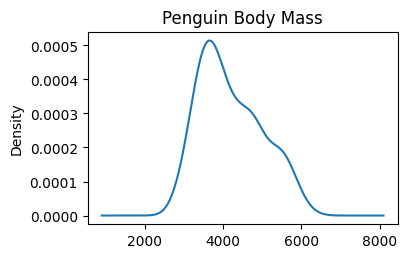

In [ ]:
# %pip install scipy    ### ensure scipy is installed; uncomment when done

# penguins — body mass or flipper length, clear multi-modal distribution
penguins = sns.load_dataset("penguins").drop(columns=\
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"])
print(penguins.head())

penguins["body_mass_g"].plot(
    kind="kde", 
    title="Penguin Body Mass",
    figsize=(4,2.5)
    )

We can also overlay KDE with histogram, which makes it clear that a KDE is a smoothed out version of histogram. 

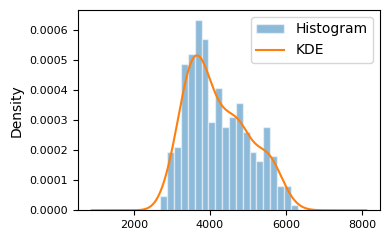

In [ ]:
penguins = sns.load_dataset("penguins").drop(columns=\
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"])

penguins["body_mass_g"].plot(
    kind="hist", bins=20,
    edgecolor="white", alpha=0.5,
    density=True,                   ### must be density=True to overlay KDE on histogram
    # title="Histogram",
    fontsize=8, 
    label="Histogram",
    figsize=(4, 2.5)
)

penguins["body_mass_g"].plot(
    kind="kde",
    # title="KDE",
    fontsize=8, 
    label="KDE"
)
plt.legend()
plt.tight_layout()

### Hexagonal Bin Plot

Hexagonal bin plots are useful for bivariate Data and is an alternative to scatterplot.

<Axes: xlabel='a', ylabel='b'>

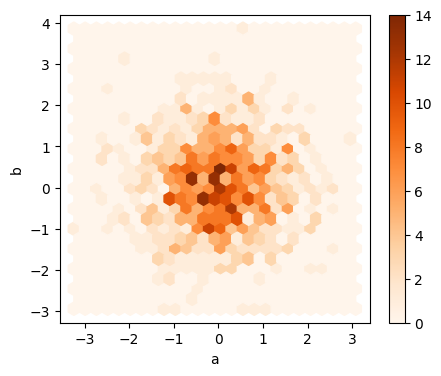

In [ ]:
np.random.seed(42)
df = pd.DataFrame(np.random.randn(1000, 2), columns=['a', 'b'])
df.plot.hexbin(x='a', y='b', 
               gridsize=25, 
               cmap='Oranges',
               figsize=(5, 4),
            )

In [ ]:
### EXERCISE 1: Histogram Fundamentals
# Goal: Visualize the distribution of `A` in `df1`.
# Requirements:
# 1) Plot a histogram for `df1['A']` with exactly 50 bins.
# 2) Set `figsize=(8, 4)` and `alpha=0.7`.
# 3) Add a title: "Distribution of A".
# Stretch: Add vertical dashed lines for the mean and median of `A`.

# Your code here


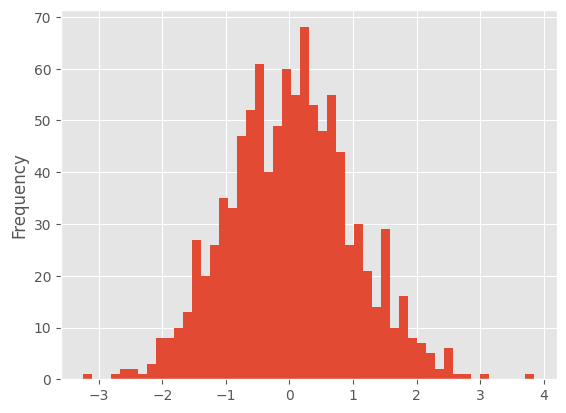

In [ ]:
# Solution
import matplotlib.pyplot as plt
df1['A'].plot.hist(bins=50)
plt.show()

In [ ]:
### EXERCISE 2: Line Plot Styling
# Goal: Show trend behavior for one feature.
# Requirements:
# 1) Plot `df1['B']` as a line plot.
# 2) Use `figsize=(8, 4)` and `lw=2`.
# 3) Set x-label to "Index" and y-label to "B values".
# Stretch: Overlay a rolling mean with window=10 on the same axes.

# Your code here


<Axes: >

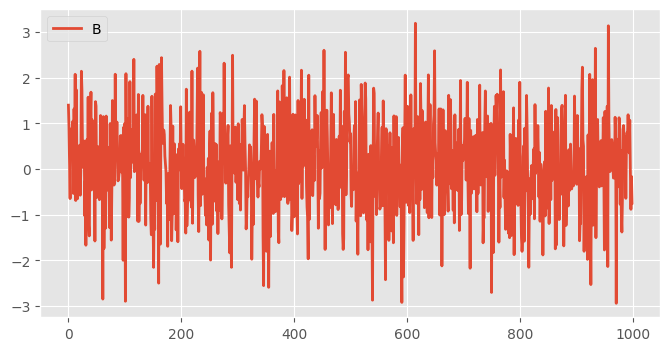

In [ ]:
# Solution
df1.plot.line(y='B', figsize=(8,4), lw=2)

In [ ]:
### EXERCISE 3: Scatter Relationship
# Goal: Examine the relationship between `A` and `B`.
# Requirements:
# 1) Create a scatter plot with `x='A'` and `y='B'`.
# 2) Set `figsize=(7, 5)`.
# 3) Set title to "A vs B".
# Stretch: Add `alpha=0.6` and compare readability.

# Your code here
